In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from scipy import interpolate
from scipy.integrate import trapezoid



In [ ]:
frequencies = np.logspace(np.log10(0.003), np.log10(3e7), int(1e5))

39999

In [67]:

frequencies = np.logspace(np.log10(0.003), np.log10(3e7), int(1e5))


folder = r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Frequency conversion RIN and FN\Pertoldi\plotting+data\plotting+data\\" #r'C:\Users\pertu\OneDrive - NKT Photonics\PhD\Laser\data\Conversion noise paper\autosave plots\plotting+data\\'
filename = 'THG FN spectra - New measurements.xlsx'
file_path = folder + filename

df698 = pd.read_excel(file_path,  sheet_name='698nm, 16.2m MZI')
freq698 = df698.iloc[:,0]
FN698_raw = df698.iloc[:, 5]
# Create an interpolation function
interp_func = interpolate.interp1d(freq698, FN698_raw, kind='linear', fill_value='extrapolate')
# Use this function to interpolate your data to match the new frequencies vector
FN698 = interp_func(frequencies)**2
 
df2095 = pd.read_excel(file_path,  sheet_name='2095nm, 10m MI') 
freq2095 = df2095.iloc[:,0]
FN2095 = df2095.iloc[:,-1]
# Create an interpolation function
interp_func = interpolate.interp1d(freq2095, FN2095, kind='linear', fill_value='extrapolate')
# Use this function to interpolate your data to match the new frequencies vector
FN2095 = interp_func(frequencies)**2


(1000.0, 10000000.0)

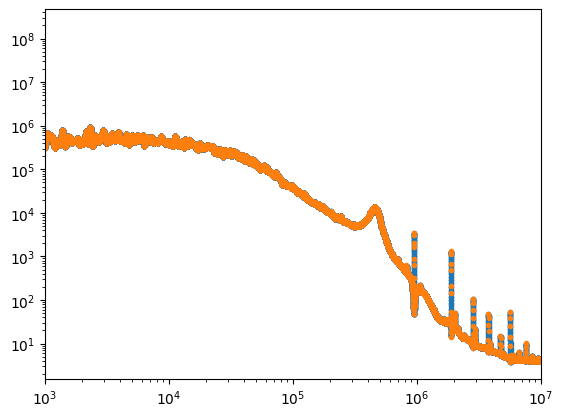

In [70]:
plt.plot(frequencies,FN698,'.')
plt.plot(freq698,FN698_raw**2,'.')

plt.xscale('log')
plt.yscale('log')
plt.xlim([1e3,1e7])

In [76]:

x_lim_start = 1e3
x_lim_end = 1e7

pump_freqs = frequencies[( (frequencies> x_lim_start) & (frequencies< x_lim_end))]
pump_FN = FN2095[( (frequencies> x_lim_start) & (frequencies< x_lim_end))]

In [149]:
freq_test = np.logspace(np.log10(x_lim_start),np.log10(x_lim_end),len(pump_freqs))

In [150]:
freq_test - pump_freqs

array([-1.76127053e-01, -1.76158400e-01, -1.76189752e-01, ...,
        1.92180320e+03,  1.92233785e+03,  1.92287265e+03])

In [80]:
def beta_sep(f):

    return 8 * np.log(2) * f /(np.pi**2)



Text(0.5, 0, 'Fourier frequency [$f$]')

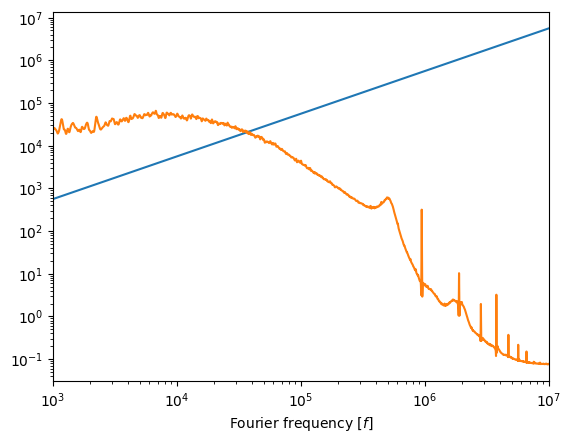

In [94]:
f = np.linspace(1e3,1e7,int(1e5))

plt.plot(pump_freqs,beta_sep(pump_freqs))
plt.plot(pump_freqs,pump_FN)
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e3,1e7])
plt.xlabel(r'Fourier frequency [$f$]')

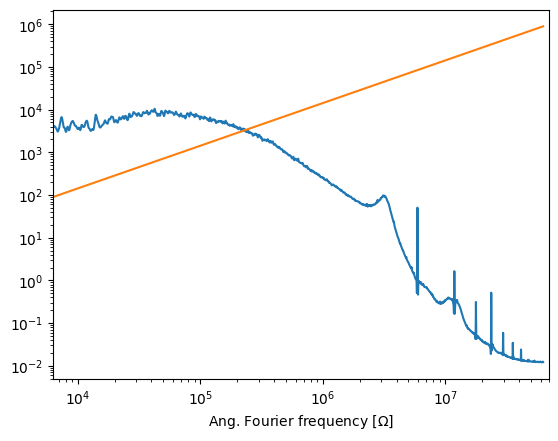

In [109]:
# plt.plot(f,beta_sep(f))
omega = 2*np.pi *pump_freqs
plt.plot(omega,pump_FN/(2*np.pi))
plt.xscale('log')
plt.yscale('log')
plt.xlim([2*np.pi*1e3,7e7])
plt.xlabel(r'Ang. Fourier frequency $[\Omega]$')

plt.plot(omega,beta_sep(omega)/(2*np.pi)**2)


array([   23898.02197153,    23888.3142211 ,    23878.60611151, ...,
       -5614772.67129749, -5616065.68226197, -5617358.99099046])

In [141]:
diff =[]
diff_ang =[]

diff = pump_FN-beta_sep(pump_freqs)
diff_ang = pump_FN/(2*np.pi)-beta_sep(omega)/(2*np.pi)**2


index_end = np.where(np.min(np.abs(diff)) == np.abs(diff))[0][0]

index_ang_end = np.where(np.min(np.abs(diff_ang)) == np.abs(diff_ang))[0][0]

In [158]:
def trap_int(power,freq):
    sum= 0
    for i in range(1,len(freq)):
        sum += (power[i-1]+power[i])*(freq[i]-freq[i-1])/2
    return sum

In [159]:
trapezoid(pump_FN[0:index_end],pump_freqs[0:index_end]),trapezoid(pump_FN[0:index_ang_end]/(2*np.pi),omega[0:index_ang_end]), trap_int(pump_FN[0:index_end],pump_freqs[0:index_end]),trap_int(pump_FN[0:index_ang_end]/(2*np.pi),omega[0:index_ang_end])


(1294025310.5095167,
 1294025310.5095167,
 1294025310.5095208,
 1294025310.5095158)